<a href="https://colab.research.google.com/github/nyee88/tvam_resin_mini/blob/pytorch-experiment/NRC_Postdoc_Project/01_Resin_Discovery_Framework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Created 'historical_lab_data.csv' with 2000 samples.
Dataset Preview (First 5 Rows):


,Resin_ID,Monomer_Type,Photoinitiator_Perc,Absorber_Perc,Ec_mJ_cm2,Dp_um
0,Resin_001,Acrylate_Standard,0.63,0.138,9.50,212.0
1,Resin_002,Epoxy_Tough,1.45,0.161,8.73,165.8
2,Resin_003,Acrylate_Standard,2.21,0.058,4.06,299.4
3,Resin_004,Acrylate_Standard,1.88,0.129,5.88,233.5
4,Resin_005,Acrylate_Standard,2.06,0.119,5.06,222.0


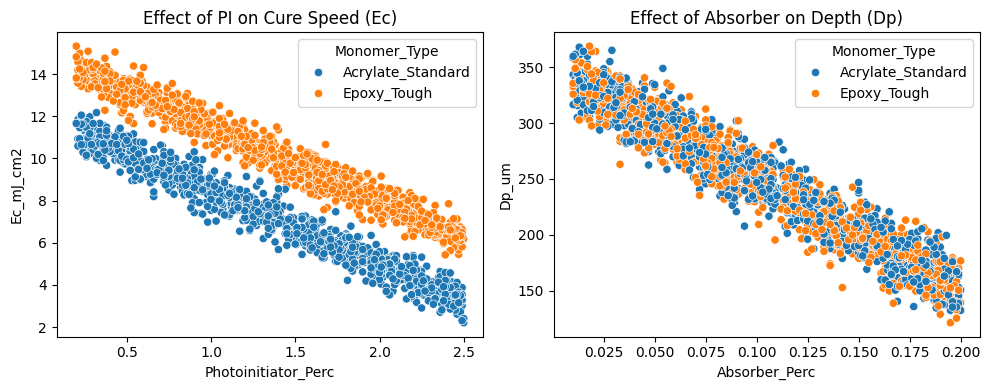

In [1]:
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- CONFIGURATION ---
# We generate the data inside the notebook so it is self-contained.
# This ensures anyone running your portfolio can reproduce your results immediately.
filename = "historical_lab_data.csv"
random.seed(42)
np.random.seed(42)  # Consistency seed
n_samples = 2000      # Larger synthetic dataset for smoother learning

# --- 1. GENERATE INGREDIENTS (The Inputs) ---
data = {
    "Resin_ID": [f"Resin_{i+1:03d}" for i in range(n_samples)],

    # Two common monomer types for 3D printing
    "Monomer_Type": np.random.choice(["Acrylate_Standard", "Epoxy_Tough"], n_samples),

    # Photoinitiator (PI): Drives the reaction. Range: 0.2% to 2.5%
    "Photoinitiator_Perc": np.round(np.random.uniform(0.2, 2.5, n_samples), 2),

    # Absorber: Controls light penetration. Range: 0.01% to 0.2%
    "Absorber_Perc": np.round(np.random.uniform(0.01, 0.2, n_samples), 3),
}

df = pd.DataFrame(data)

# --- 2. SIMULATE PHYSICS PROPERTIES (The Outputs) ---
# We use "Ground Truth" chemical logic so the model learns real relationships.

# Logic for Critical Energy (Ec):
# - More PI = Faster Cure (Lower Ec)
# - Epoxies are generally slower (Higher Ec) than Acrylates
def calc_ec(row):
    base_ec = 12.0
    chem_factor = 3.0 if row["Monomer_Type"] == "Epoxy_Tough" else 0.0
    pi_effect = -3.5 * row["Photoinitiator_Perc"] # More PI lowers Ec
    noise = np.random.normal(0, 0.5)
    return max(1.5, base_ec + chem_factor + pi_effect + noise)

# Logic for Penetration Depth (Dp):
# - More Absorber = Shallower Depth (Lower Dp)
# - Dp follows a logarithmic decay law (Beer-Lambert Law approximation)
def calc_dp(row):
    base_dp = 350.0
    # Strong inverse effect of absorber
    abs_effect = -1000.0 * row["Absorber_Perc"]
    noise = np.random.normal(0, 15)
    return max(50.0, base_dp + abs_effect + noise)

df["Ec_mJ_cm2"] = df.apply(calc_ec, axis=1).round(2)
df["Dp_um"] = df.apply(calc_dp, axis=1).round(1)

# --- 3. SAVE TO CSV (Virtual) ---
df.to_csv(filename, index=False)

print(f"Created '{filename}' with {n_samples} samples.")
print("Dataset Preview (First 5 Rows):")
display(df.head())

# Optional: Quick visual check
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x="Photoinitiator_Perc", y="Ec_mJ_cm2", hue="Monomer_Type")
plt.title("Effect of PI on Cure Speed (Ec)")

plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x="Absorber_Perc", y="Dp_um", hue="Monomer_Type")
plt.title("Effect of Absorber on Depth (Dp)")
plt.tight_layout()
plt.show()

In [2]:
# --- CELL 2: LEARN PHYSICS FROM CHEMISTRY (PYTORCH EDITION WITH HELD-OUT TEST SET) ---

# Goal:
#   1) Load the synthetic "historical" resin data
#   2) Train a PyTorch regressor to predict Ec and Dp from chemistry inputs
#   3) Evaluate on a held-out test set (so we don't just fit the noise)
#   4) Define a helper that proposes new formulations for a target Ec/Dp

import random
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# Reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Load the "historical" data generated in Cell 1
filename = "historical_lab_data.csv"
df = pd.read_csv(filename)

print(f"Loaded {len(df)} historical resin experiments from '{filename}'")
display(df.head())

# 2. Prepare features (chemistry) and targets (physics)
#    - Inputs: Monomer_Type (categorical), Photoinitiator_Perc, Absorber_Perc
#    - Outputs: Ec_mJ_cm2 (cure speed), Dp_um (penetration depth)

feature_cols = ["Monomer_Type", "Photoinitiator_Perc", "Absorber_Perc"]
X_raw = df[feature_cols]

# One-hot encode monomer family; drop_first=True to avoid redundant column
X_encoded = pd.get_dummies(
    X_raw,
    columns=["Monomer_Type"],
    drop_first=True
)
feature_names = X_encoded.columns.tolist()

X_np = X_encoded.values.astype(np.float32)
y_np = np.column_stack([
    df["Ec_mJ_cm2"].values.astype(np.float32),
    df["Dp_um"].values.astype(np.float32),
])

print("\nFeature matrix columns used by the PyTorch model:")
print(feature_names)

# Standardize features and targets for smoother optimization
X_scaler = StandardScaler()
y_scaler = StandardScaler()
X_scaled = X_scaler.fit_transform(X_np)
y_scaled = y_scaler.fit_transform(y_np)

# 3. Train/test split so we can measure generalization
X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
    X_scaled, y_scaled,
    test_size=0.25,
    random_state=42
)

X_train = torch.tensor(X_train_np, dtype=torch.float32)
X_test = torch.tensor(X_test_np, dtype=torch.float32)
y_train = torch.tensor(y_train_np, dtype=torch.float32)
y_test = torch.tensor(y_test_np, dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)

print(f"\nTrain size: {X_train.shape[0]} samples")
print(f"Test size : {X_test.shape[0]} samples")

# 4. Define and train a slightly larger multilayer perceptron for joint Ec/Dp regression

class ResinRegressor(nn.Module):
    def __init__(self, in_dim: int):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(in_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 2),
        )

    def forward(self, x):
        return self.network(x)

model = ResinRegressor(in_dim=X_train.shape[1]).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Simple mini-batch training loop
model.train()
epochs = 400
for epoch in range(epochs):
    running_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * xb.size(0)

    if (epoch + 1) % 100 == 0:
        avg_loss = running_loss / len(train_loader.dataset)
        print(f"Epoch {epoch + 1:03d} | train MSE {avg_loss:.4f}")

# 5. Evaluate on the held-out test set (convert predictions back to original scale)
model.eval()
with torch.no_grad():
    y_pred_train_scaled = model(X_train.to(device)).cpu().numpy()
    y_pred_test_scaled = model(X_test.to(device)).cpu().numpy()

# Undo standardization to report metrics in original units
y_pred_train = y_scaler.inverse_transform(y_pred_train_scaled)
y_pred_test = y_scaler.inverse_transform(y_pred_test_scaled)

train_targets = y_scaler.inverse_transform(y_train_np)
test_targets = y_scaler.inverse_transform(y_test_np)

y_pred_ec_train, y_pred_dp_train = y_pred_train[:, 0], y_pred_train[:, 1]
y_pred_ec_test, y_pred_dp_test = y_pred_test[:, 0], y_pred_test[:, 1]

y_ec_train, y_dp_train = train_targets[:, 0], train_targets[:, 1]
y_ec_test, y_dp_test = test_targets[:, 0], test_targets[:, 1]

print("\nPyTorch model performance on held-out TEST set:")

nn_ec_r2  = r2_score(y_ec_test, y_pred_ec_test)
nn_ec_mae = mean_absolute_error(y_ec_test, y_pred_ec_test)
nn_dp_r2  = r2_score(y_dp_test, y_pred_dp_test)
nn_dp_mae = mean_absolute_error(y_dp_test, y_pred_dp_test)

print(f"   - Ec  R: {nn_ec_r2:.3f}   MAE: {nn_ec_mae:.2f} mJ/cm")
print(f"   - Dp  R: {nn_dp_r2:.3f}   MAE: {nn_dp_mae:.1f} µm")

# 6. Helper: search a "virtual" library of candidate formulations
#    and pick the one whose predicted Ec/Dp are closest to a target.

def predict_properties(encoded_features: np.ndarray) -> np.ndarray:
    model.eval()
    with torch.no_grad():
        inputs_scaled = X_scaler.transform(encoded_features)
        inputs = torch.as_tensor(inputs_scaled, dtype=torch.float32, device=device)
        preds_scaled = model(inputs).cpu().numpy()
        preds = y_scaler.inverse_transform(preds_scaled)
    return preds


def suggest_formulation(target_ec, target_dp, virtual_samples=5000):
    """
    Search a random virtual library of formulations and return the one
    whose predicted Ec/Dp are closest (in normalized error) to the target.

    target_ec, target_dp : desired cure energy and penetration depth
    virtual_samples      : how many random formulations to explore
    """

    # Use the observed ranges from the historical data as bounds
    pi_min, pi_max = df["Photoinitiator_Perc"].min(), df["Photoinitiator_Perc"].max()
    abs_min, abs_max = df["Absorber_Perc"].min(), df["Absorber_Perc"].max()

    # Build a virtual library
    virtual_df = pd.DataFrame({
        "Photoinitiator_Perc": np.random.uniform(pi_min, pi_max, virtual_samples),
        "Absorber_Perc":      np.random.uniform(abs_min, abs_max, virtual_samples),
        # One-hot column must match the encoded training data
        "Monomer_Type_Epoxy_Tough": np.random.choice([0, 1], size=virtual_samples),
    })

    # Order columns to match the feature matrix used during training
    X_virtual = virtual_df[feature_names].values.astype(np.float32)

    # Predict Ec and Dp for each virtual formulation using the PyTorch model
    virtual_preds = predict_properties(X_virtual)
    virtual_df["Pred_Ec"] = virtual_preds[:, 0]
    virtual_df["Pred_Dp"] = virtual_preds[:, 1]

    # Normalized error relative to the target (simple 2D distance)
    eps = 1e-6
    ec_scale = max(abs(target_ec), eps)
    dp_scale = max(abs(target_dp), eps)

    virtual_df["Error"] = np.sqrt(
        ((virtual_df["Pred_Ec"] - target_ec) / ec_scale) ** 2 +
        ((virtual_df["Pred_Dp"] - target_dp) / dp_scale) ** 2
    )

    # Pick the best candidate
    best_match = virtual_df.sort_values("Error").iloc[0]

    monomer_name = (
        "Epoxy_Tough"
        if best_match["Monomer_Type_Epoxy_Tough"] == 1
        else "Acrylate_Standard"
    )

    print(f"\n🧪 AI Recommendation for Target (Ec={target_ec}, Dp={target_dp}):")
    print(f"   - Monomer:         {monomer_name}")
    print(f"   - Photoinitiator:  {best_match['Photoinitiator_Perc']:.2f}%")
    print(f"   - Absorber:        {best_match['Absorber_Perc']:.3f}%")
    print(f"   - Predicted Ec:    {best_match['Pred_Ec']:.2f} mJ/cm²")
    print(f"   - Predicted Dp:    {best_match['Pred_Dp']:.1f} µm")

    return best_match

Loaded 2000 historical resin experiments from 'historical_lab_data.csv'


,Resin_ID,Monomer_Type,Photoinitiator_Perc,Absorber_Perc,Ec_mJ_cm2,Dp_um
0,Resin_001,Acrylate_Standard,0.63,0.138,9.50,212.0
1,Resin_002,Epoxy_Tough,1.45,0.161,8.73,165.8
2,Resin_003,Acrylate_Standard,2.21,0.058,4.06,299.4
3,Resin_004,Acrylate_Standard,1.88,0.129,5.88,233.5
4,Resin_005,Acrylate_Standard,2.06,0.119,5.06,222.0



Feature matrix columns used by the PyTorch model:
['Photoinitiator_Perc', 'Absorber_Perc', 'Monomer_Type_Epoxy_Tough']

Train size: 1500 samples
Test size : 500 samples
Epoch 100 | train MSE 0.0536
Epoch 200 | train MSE 0.0513
Epoch 300 | train MSE 0.0497
Epoch 400 | train MSE 0.0471

PyTorch model performance on held-out TEST set:
   - Ec  R: 0.964   MAE: 0.42 mJ/cm²
   - Dp  R: 0.899   MAE: 13.5 µm


In [ ]:
from sklearn.ensemble import RandomForestRegressor

# --- Random Forest baseline on original-scale features ---

# Re-use the same train/test split pattern (random_state=42)
# but on the original, unscaled X_np / y_np so RF sees values in real units.
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_np, y_np,
    test_size=0.25,
    random_state=42,
)

# Separate Ec and Dp targets
y_ec_train_rf = y_train_rf[:, 0]
y_dp_train_rf = y_train_rf[:, 1]
y_ec_test_rf  = y_test_rf[:, 0]
y_dp_test_rf  = y_test_rf[:, 1]

# Ec model
rf_ec = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
)
rf_ec.fit(X_train_rf, y_ec_train_rf)
y_ec_pred_rf = rf_ec.predict(X_test_rf)

# Dp model
rf_dp = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
)
rf_dp.fit(X_train_rf, y_dp_train_rf)
y_dp_pred_rf = rf_dp.predict(X_test_rf)

# Metrics in the same style as the NN
rf_ec_r2  = r2_score(y_ec_test_rf, y_ec_pred_rf)
rf_ec_mae = mean_absolute_error(y_ec_test_rf, y_ec_pred_rf)
rf_dp_r2  = r2_score(y_dp_test_rf, y_dp_pred_rf)
rf_dp_mae = mean_absolute_error(y_dp_test_rf, y_dp_pred_rf)

print("\nRandom Forest performance on held-out TEST set:")
print(f"   - Ec  R: {rf_ec_r2:.3f}   MAE: {rf_ec_mae:.2f} mJ/cm")
print(f"   - Dp  R: {rf_dp_r2:.3f}   MAE: {rf_dp_mae:.1f} µm")



In [ ]:
results = pd.DataFrame([
    {
        "Model": "RandomForest",
        "Target": "Ec",
        "R2_test": rf_ec_r2,
        "MAE_test": rf_ec_mae,
    },
    {
        "Model": "RandomForest",
        "Target": "Dp",
        "R2_test": rf_dp_r2,
        "MAE_test": rf_dp_mae,
    },
    {
        "Model": "PyTorch MLP",
        "Target": "Ec",
        "R2_test": nn_ec_r2,
        "MAE_test": nn_ec_mae,
    },
    {
        "Model": "PyTorch MLP",
        "Target": "Dp",
        "R2_test": nn_dp_r2,
        "MAE_test": nn_dp_mae,
    },
])

results


In [ ]:
from sklearn.ensemble import RandomForestRegressor

# --- Random Forest baseline on original-scale features ---

# Re-use the same train/test split pattern (random_state=42)
# but on the original, unscaled X_np / y_np so RF sees values in real units.
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_np, y_np,
    test_size=0.25,
    random_state=42,
)

# Separate Ec and Dp targets
y_ec_train_rf = y_train_rf[:, 0]
y_dp_train_rf = y_train_rf[:, 1]
y_ec_test_rf  = y_test_rf[:, 0]
y_dp_test_rf  = y_test_rf[:, 1]

# Ec model
rf_ec = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
)
rf_ec.fit(X_train_rf, y_ec_train_rf)
y_ec_pred_rf = rf_ec.predict(X_test_rf)

# Dp model
rf_dp = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
)
rf_dp.fit(X_train_rf, y_dp_train_rf)
y_dp_pred_rf = rf_dp.predict(X_test_rf)

# Metrics in the same style as the NN
rf_ec_r2  = r2_score(y_ec_test_rf, y_ec_pred_rf)
rf_ec_mae = mean_absolute_error(y_ec_test_rf, y_ec_pred_rf)
rf_dp_r2  = r2_score(y_dp_test_rf, y_dp_pred_rf)
rf_dp_mae = mean_absolute_error(y_dp_test_rf, y_dp_pred_rf)

print("\nRandom Forest performance on held-out TEST set:")
print(f"   - Ec  R: {rf_ec_r2:.3f}   MAE: {rf_ec_mae:.2f} mJ/cm")
print(f"   - Dp  R: {rf_dp_r2:.3f}   MAE: {rf_dp_mae:.1f} µm")



In [ ]:
results = pd.DataFrame([
    {
        "Model": "RandomForest",
        "Target": "Ec",
        "R2_test": rf_ec_r2,
        "MAE_test": rf_ec_mae,
    },
    {
        "Model": "RandomForest",
        "Target": "Dp",
        "R2_test": rf_dp_r2,
        "MAE_test": rf_dp_mae,
    },
    {
        "Model": "PyTorch MLP",
        "Target": "Ec",
        "R2_test": nn_ec_r2,
        "MAE_test": nn_ec_mae,
    },
    {
        "Model": "PyTorch MLP",
        "Target": "Dp",
        "R2_test": nn_dp_r2,
        "MAE_test": nn_dp_mae,
    },
])

results


In [3]:
# --- CELL 3: USE THE MODEL TO PROPOSE A FORMULATION & CHECK AGAINST GROUND TRUTH ---

# 1. Ask the model for a resin that meets our target Ec and Dp
target_ec = 8.0
target_dp = 175.0

best = suggest_formulation(
    target_ec=target_ec,
    target_dp=target_dp,
    virtual_samples=5000
)

# 2. Recover the monomer family from the one-hot column
monomer_name = (
    "Epoxy_Tough"
    if best["Monomer_Type_Epoxy_Tough"] == 1
    else "Acrylate_Standard"
)

# 3. Compare model prediction to the "true" Ec/Dp from the synthetic physics model

# Build a row-like object with the same keys used in calc_ec / calc_dp
row = {
    "Monomer_Type": monomer_name,
    "Photoinitiator_Perc": float(best["Photoinitiator_Perc"]),
    "Absorber_Perc": float(best["Absorber_Perc"]),
}

true_ec = calc_ec(row)
true_dp = calc_dp(row)

print("\nGround-truth check using the underlying physics model:")
print(f"   - Monomer:             {monomer_name}")
print(f"   - PI % / Absorber %:   {best['Photoinitiator_Perc']:.2f} / {best['Absorber_Perc']:.3f}")
print(f"   - Target Ec / Dp:      {target_ec:.2f} mJ/cm² / {target_dp:.1f} µm")
print(f"   - Model-pred Ec / Dp:  {best['Pred_Ec']:.2f} mJ/cm² / {best['Pred_Dp']:.1f} µm")
print(f"   - True Ec / Dp:        {true_ec:.2f} mJ/cm² / {true_dp:.1f} µm")



🧪 AI Recommendation for Target (Ec=8.0, Dp=175.0):
   - Monomer:         Epoxy_Tough
   - Photoinitiator:  1.95%
   - Absorber:        0.168%
   - Predicted Ec:    7.99 mJ/cm²
   - Predicted Dp:    175.6 µm

Ground-truth check using the underlying physics model:
   - Monomer:             Epoxy_Tough
   - PI % / Absorber %:   1.95 / 0.168
   - Target Ec / Dp:      8.00 mJ/cm² / 175.0 µm
   - Model-pred Ec / Dp:  7.99 mJ/cm² / 175.6 µm
   - True Ec / Dp:        8.44 mJ/cm² / 165.4 µm


GOO GOO DOOLS